## Music League Stats

All of the data is scraped into a pandas dataframe with each row being an entry, with submitter name, song id, votes from all other players, and other stats scraped from the spotify API.

In [10]:
from pathlib import Path
from datetime import datetime, timedelta
from itertools import repeat

import numpy as np
import matplotlib.pyplot as plt
from  matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.dates as mdates


from scraper import translator, create_dataframe
from spotify_data import get_spotify_data, get_playlist, playlists

Dump the files from the downloaded webpage into `/music_league/` in the root of this directory. It has to be the full html and media download, just html doesn't contain the voting information unfortunately.

In [11]:
path = Path("../music_league_2/")

df, names = create_dataframe(path=path, translator=translator) # translator is a dictionary that converts music league names to actual names
df = get_spotify_data(music_league_df=df)

b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many requests'
b'Too many re

KeyboardInterrupt: 

In [ ]:
round_names = (
    "Boxing Entrance",
    "Best Sample",
    "Best Live Version",
    "Obscurity",
    "Best solo breakout",
    "Best summer song",
    "To the Polls",
    "Song with a drink in the title",
    "One hit wonder",
    "Riskaware anthem"
)

df["round_name"] = df["round"].astype(int).map(lambda i: round_names[i-1])

In [ ]:
winning_order = df.groupby(df["submitter"])[names].sum().sum(axis=1)
winning_order = winning_order.sort_values(ascending=False).index

df["round_score"] = df[names].sum(axis=1)

# Round winners

for round_name, (round, scores) in zip(round_names, df.groupby("round")):
    winning_score = scores["round_score"].max()
    a = f"Round {round:<4} | {round_name}"
    print(a + "\n" + '-'*len(a))
    for _, row in scores[scores["round_score"] == winning_score][["submitter", "track_name", "round_score"]].iterrows():
        print(f"{row['submitter']:10} | {row['track_name']:40} | {int(row['round_score'])}")
    print()


Round 1    | Boxing Entrance
----------------------------


KeyError: "['track_name'] not in index"

## Biggest scores per round

In [ ]:
df.sort_values("round_score", ascending=False).iloc[:10][["round_name", "submitter", "track_name", "round_score"]]

In [ ]:
df.sort_values("round_score", ascending=True).iloc[:10][["round_name", "submitter", "track_name", "round_score"]]

## Voting Matrix

The voting matrix shows the net votes of all competitors across all of the rounds. Rows are the points received, columns the points given. The rows and columns are sorted into the final order of the league

In [ ]:
# arr has shape (num_rounds, num_competitors, num_competitors)
# Any missing values are filled with 0.0

arr = np.concatenate([
        group.reindex(winning_order, fill_value=0.0).to_numpy()[None, :, :]
        for _, group in df.set_index(df["submitter"]).groupby("round")[winning_order]], axis=0)
correlation = np.sum(arr, axis=0)

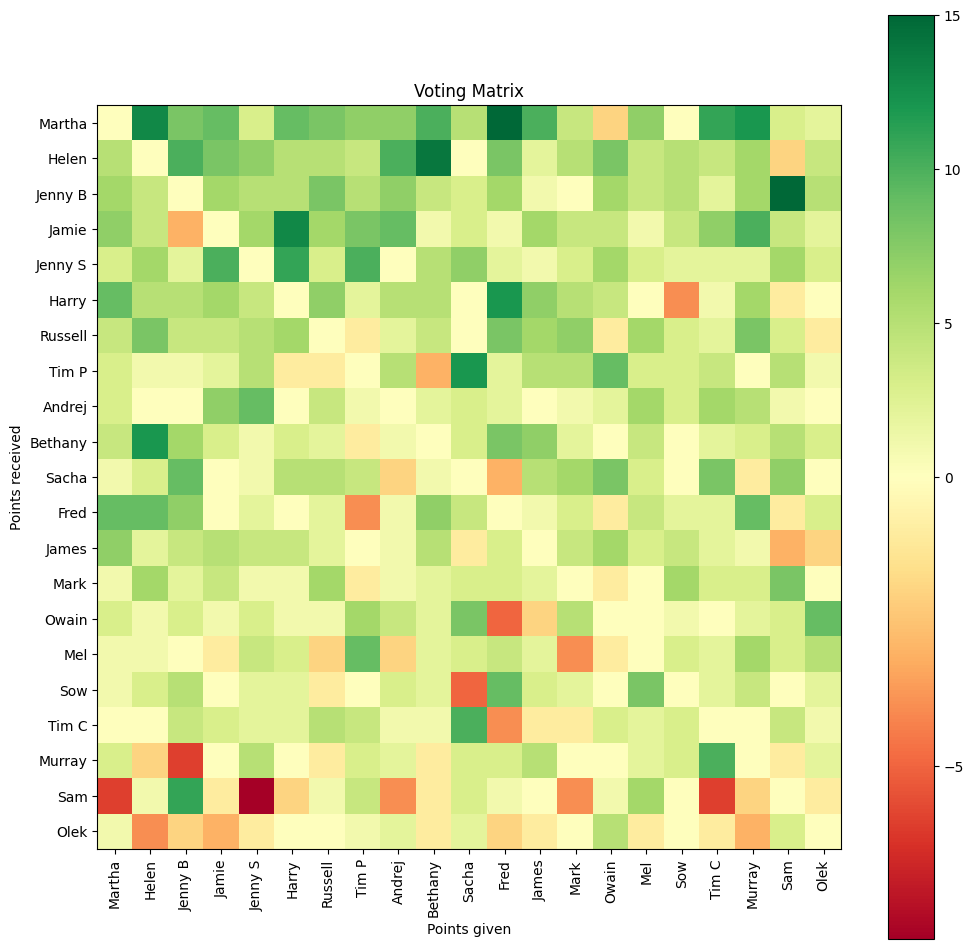

In [ ]:
fig, ax = plt.subplots(figsize=(12,12))

cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256)
norm = TwoSlopeNorm(vmin=np.min(correlation),
                        vcenter=0,
                        vmax=np.max(correlation))

plt.imshow(correlation, cmap='RdYlGn', norm=norm, interpolation='nearest')
plt.xticks(np.arange(len(winning_order)), winning_order, rotation='vertical')
plt.yticks(np.arange(len(winning_order)), winning_order)
plt.xlabel("Points given")
plt.ylabel("Points received")
plt.title("Voting Matrix")


cbar = plt.colorbar()

plt.show()

List the top ten biggest stans and haters

In [ ]:
most_correlated = np.unravel_index(np.argsort(-correlation.reshape(-1))[:10], correlation.shape)
for row, col in zip(*most_correlated):
    print(f"{winning_order[col]} for {winning_order[row]}: {int(correlation[row, col])}")


Fred for Martha: 15
Sam for Jenny B: 15
Bethany for Helen: 14
Helen for Martha: 13
Harry for Jamie: 13
Murray for Martha: 12
Sacha for Tim P: 12
Fred for Harry: 12
Helen for Bethany: 12
Harry for Jenny S: 11


In [ ]:
biggest_haters = np.unravel_index(np.argsort(correlation.reshape(-1))[:10], correlation.shape)
for row, col in zip(*biggest_haters):
    print(f"{winning_order[col]} for {winning_order[row]}: {int(correlation[row, col])}")


Jenny S for Sam: -8
Jenny B for Murray: -6
Martha for Sam: -6
Tim C for Sam: -6
Sacha for Sow: -5
Fred for Owain: -5
Mark for Mel: -4
Tim P for Fred: -4
Sow for Harry: -4
Fred for Tim C: -4


## Voting Correlation

See who votes similarly... and who doesn't

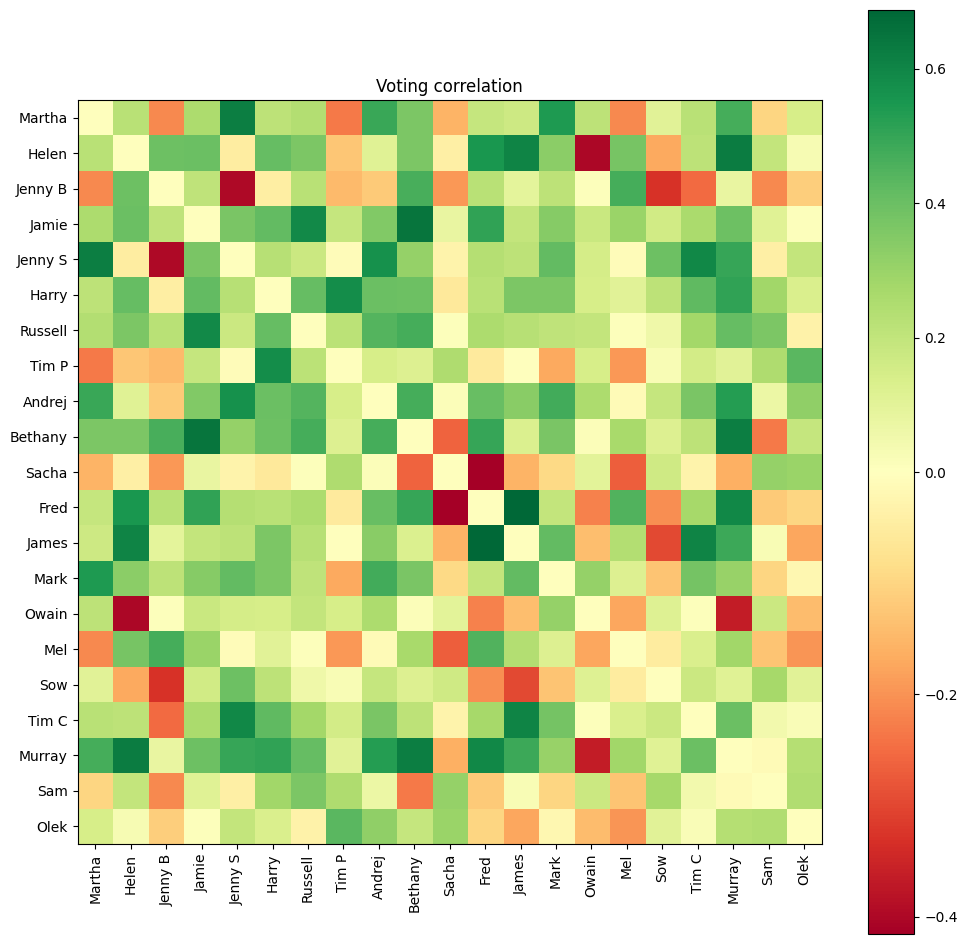

In [ ]:
# Sort arr into an array that's lists of each competitors votes per round

voting_correlation = np.corrcoef(np.vstack(correlation).T)
np.fill_diagonal(voting_correlation, 0.0)

fig, ax = plt.subplots(figsize=(12,12))

cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256)
norm = TwoSlopeNorm(vmin=np.min(voting_correlation),
                        vcenter=0,
                        vmax=np.max(voting_correlation))

plt.imshow(voting_correlation, cmap='RdYlGn', norm=norm, interpolation='nearest')
plt.xticks(np.arange(len(winning_order)), winning_order, rotation='vertical')
plt.yticks(np.arange(len(winning_order)), winning_order)
plt.title("Voting correlation")


cbar = plt.colorbar()

plt.show()

In [ ]:
most_correlated = np.unravel_index(np.argsort(-voting_correlation.reshape(-1))[:20:2], correlation.shape)
for row, col in zip(*most_correlated):
    print(f"{winning_order[col]} and {winning_order[row]}: {voting_correlation[row, col]:.2f}")

James and Fred: 0.69
Bethany and Jamie: 0.65
Helen and Murray: 0.63
Jenny S and Martha: 0.62
Murray and Bethany: 0.62
James and Helen: 0.60
Tim C and James: 0.60
Tim C and Jenny S: 0.59
Murray and Fred: 0.59
Jamie and Russell: 0.59


In [ ]:
most_correlated = np.unravel_index(np.argsort(voting_correlation.reshape(-1))[:20:2], correlation.shape)
for row, col in zip(*most_correlated):
    print(f"{winning_order[col]} and {winning_order[row]}: {voting_correlation[row, col]:.2f}")

Sacha and Fred: -0.42
Helen and Owain: -0.40
Jenny S and Jenny B: -0.40
Owain and Murray: -0.36
Jenny B and Sow: -0.33
Sow and James: -0.30
Mel and Sacha: -0.27
Bethany and Sacha: -0.26
Jenny B and Tim C: -0.25
Martha and Tim P: -0.23


## Genre Correlation

See who submits similar genres

In [ ]:
unique_genres = set()

for submitter in winning_order:
    rest = set(reduce(add, df[df.submitter != submitter]["genres"].values))
    unique_genres |= set(reduce(add, df[df.submitter == submitter]["genres"])).difference(rest)

all_genres = list({genre for genres in df.genres for genre in genres}.difference(unique_genres))
from functools import reduce
from operator import add
x = df.groupby("submitter")["genres"].apply(lambda x: reduce(add, x)).reindex(winning_order).map(set)

matrix = np.zeros((len(winning_order), len(all_genres)))

for i, genres in enumerate(x.values):
    for j, genre in enumerate(all_genres):
        if genre in genres:
            matrix[i][j] = 1.0

correlation = np.corrcoef(matrix)
np.fill_diagonal(correlation, 0.0)

fig, ax = plt.subplots(figsize=(12,12))

cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256)
norm = TwoSlopeNorm(vmin=np.min(correlation),
                        vcenter=0,
                        vmax=np.max(correlation))

plt.imshow(correlation, cmap='RdYlGn', norm=norm, interpolation='nearest')
plt.xticks(np.arange(len(winning_order)), winning_order, rotation='vertical')
plt.yticks(np.arange(len(winning_order)), winning_order)


cbar = plt.colorbar()

plt.show()

In [ ]:
x = arr.reshape(-1, len(winning_order))
x[x <= 0.0] = np.nan
a = np.nanmean(x, axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_title("Average positive vote")

ax.bar(np.arange(len(winning_order)), a[np.argsort(a)])
ax.set_xticks(np.arange(len(winning_order)), labels=[winning_order[i] for i in np.argsort(a)], rotation="vertical")

plt.show()

In [ ]:
# Average song age

df["song_age_seconds"] = (datetime.now() - df["date"]).dt.total_seconds()
ages = df.groupby("submitter")["song_age_seconds"].mean().sort_values().map(lambda x: datetime.now() - timedelta(seconds=x))

fig, ax = plt.subplots(figsize=(12, 4), layout="constrained")
ax.set(title="Average song age")

levels = [(i % 3) / 3 + 1 for i in range(len(ages))]

# The vertical stems.
ax.vlines(ages, 0, levels,
          color=[("tab:red", 1)
                 for _ in ages])
# The baseline.
ax.axhline(0, c="black")
# The markers on the baseline
ax.plot(ages, np.zeros_like(ages), "ko", mfc="tab:red")

# Annotate the lines.
for date, level, name in zip(ages, levels, ages.index):
    ax.annotate(name, xy=(date, level),
                xytext=(-3, np.sign(level)*3), textcoords="offset points",
                verticalalignment="bottom" if level > 0 else "top",
                bbox=dict(boxstyle='square', pad=0, lw=0, fc=(1, 1, 1, 0.7)))

ax.yaxis.set(major_locator=mdates.YearLocator(),
             major_formatter=mdates.DateFormatter("%Y"))

# Remove the y-axis and some spines.
ax.yaxis.set_visible(False)
ax.spines[["left", "top", "right"]].set_visible(False)

ax.margins(y=0.1)
plt.show()

In [ ]:
# Does song age correlate with overall ranking?

np.corrcoef(np.c_[ages.reindex(winning_order).argsort(), np.arange(len(ages))].T)

In [ ]:
lengths = df.groupby("submitter")["duration"].mean().sort_values()

fig, ax = plt.subplots(figsize=(14, 8))

ax.bar(np.arange(len(lengths)), lengths)
ax.set_xticks(np.arange(len(winning_order)), lengths.index, rotation='vertical')
ax.set_title("Mean song length")
ax.set_ylabel("Song length (s)")
plt.show()

In [ ]:
df.sort_values("duration", ascending=False)[["submitter", "track_name", "duration"]].iloc[:10]

In [ ]:
df[df["round"]!=8].sort_values("duration")[["submitter", "track_name", "duration"]].iloc[:10]

In [ ]:
# Energy

df.groupby("submitter")["energy"].mean().sort_values(ascending=False)

In [ ]:
# popularity

fig, ax = plt.subplots(figsize=(12, 8))

pop = df.groupby("submitter")["popularity"].mean().sort_values(ascending=False)
ax.bar(range(len(pop)), pop)
ax.set_xticks(range(len(pop)), pop.index, rotation="vertical")


ax.set_title("Mean popularity")

plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.bar(np.arange(len(pop)), pop.reindex(winning_order))
ax.set_xticks(range(len(pop)), winning_order, rotation="vertical")
ax.set_ylim(min(pop)*0.95, max(pop)*1.05)
ax.set_ylabel("Spotify popularity score")

plt.title("Mean popularity in league winning order")

plt.show()

In [ ]:
playlists = [get_playlist(playlist) for playlist in playlists]

In [ ]:
i, a = list(df.groupby("round"))[0]

vals = []

for i, a in df.groupby("round"):
    vals.append(a.sort_values("round_score", ascending=False)["song_id"].map(lambda x: playlists[i-1].index(x)))

vals[0]

In [ ]:
rankings = np.array([i for df in vals for i in range(len(df))])
playlist_order = np.array([i for df in vals for i in df.values])

# Add noise
playlist_order = playlist_order + np.random.random(*playlist_order.shape) * 0.2

plt.xlabel("round ranking")
plt.ylabel("playlist order")

plt.plot(rankings, playlist_order, "kx")
plt.show()


In [ ]:
np.corrcoef(rankings, playlist_order)

In [ ]:
negative_votes = np.where(arr < 0, arr, 0)

negative_scores = np.sum(negative_votes, axis=(0, 2))

order = np.argsort(negative_scores)

fig, ax = plt.subplots(figsize=(12, 8))

ax.bar(np.arange(len(winning_order)), np.sort(negative_scores))
ax.set_xticks(range(len(winning_order)), winning_order[order], rotation="vertical")
ax.set_ylabel("Score")
ax.set_title("If only downvotes counted...")

plt.show()


In [ ]:
ignore_zeros = np.where(arr == 0, np.nan, arr)
stds = np.nanstd(ignore_zeros, axis=-1)
controversy = np.nanmean(stds, axis=0)

fig, ax = plt.subplots(figsize=(12, 8))

ax.bar(np.arange(len(winning_order)), sorted(controversy))
ax.set_xticks(range(len(winning_order)), winning_order[np.argsort(controversy)], rotation="vertical")
ax.set_ylabel("Controversy")
ax.set_title("Attempted controversy measure")

plt.show()

In [ ]:
x = np.where(df[winning_order].to_numpy() == 0, np.nan, df[winning_order].to_numpy())
df["controversy"] = np.nanstd(x, axis=1)
df.sort_values("controversy", ascending=False)[["submitter", "track_name", "controversy"]].iloc[:10]

In [ ]:
arr = np.concatenate([
        group.reindex(winning_order, fill_value=0.0).to_numpy()[None, :, :]
        for _, group in df.set_index(df["submitter"]).groupby("round")[winning_order]], axis=0)

positive = np.where(arr > 0.0, arr, np.nan)
negative = np.where(arr < 0.0, arr, np.nan)

positive_scores = np.nansum(positive, axis=(-1))
negative_scores = np.nansum(negative, axis=(-1))


total = positive_scores + negative_scores
